In [1]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [ ]:
# import dataiku
# from dataiku import pandasutils as pdu
import pandas as pd
import os

In [ ]:
# Read the dataset as a Pandas dataframe in memory
# Ruta relativa al archivo de datos
DATA_PATH = "C:\Users\Javi\Desktop\A 5º Mat-Info\TFG Mates\Mathematics-Dissertation-Survival-Modeling-Javier\data\processed\icu_master.csv"

def get_data(filepath=DATA_PATH):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"No se encuentra el archivo en {filepath}. ¿Has descargado los datos?")
    
    # Cargar datos
    df = pd.read_csv(filepath)
    return df

# Uso
df = get_data()

#dataset_icu_master = dataiku.Dataset("icu_master")
#df = dataset_icu_master.get_dataframe(limit=100000)

In [4]:
# Get some simple descriptive statistics
pdu.audit(df)

,_a_variable,_b_data_type,_c_cardinality,_d_missings,_e_sample_values
0,subject_id,int64,36931,0,"[10584718, 14671248]"
1,hadm_id,int64,42710,0,"[23485217, 21908050]"
2,stay_id,int64,43386,0,"[36809832, 34687545]"
3,intime,object,43383,0,"[2165-02-27 21:41:10, 2125-11-09 22:48:10]"
4,outtime,object,43385,0,"[2165-03-06 11:09:58, 2125-11-11 15:21:27]"
5,admittime,object,42557,0,"[2165-02-12 15:41:00, 2125-11-05 18:28:00]"
6,dischtime,object,42578,0,"[2165-03-06 08:20:00, 2125-11-12 16:30:00]"
7,deathtime,object,5737,37478,"[2165-03-06 08:20:00, nan]"
8,hospital_expire_flag,int64,2,0,"[1, 0]"
9,sex,object,2,0,"[M, F]"


## 1. Variables y Dataframe

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# -----------------------------
# Definimos columnas a usar
# -----------------------------
id_features = ["subject_id", "hadm_id", "stay_id"]

categorical_features = [
    "sex",
    "unit_type",
    "admission_location",
    "race",
]
# cuidado porque hemos tomado variables gcs como númericas, discutirlo
numerical_features = [
    "age",
    "height",
    "weight",
    "gcs_motor",
    "gcs_verbal",
    "hour_of_admission",
    # puedes añadir "time_since_admission" si quieres, pero cuidado con interpretar
]

# Outcome de supervivencia
time_col = "time"
event_col = "event"

# Dataset de trabajo (sin IDs)
df_model = df[categorical_features + numerical_features + [time_col, event_col]].copy()

# considerar añadir mascara ya que me doy cuenta de que hay 35 personas con time negativo
# mask_valid = df_model["time"] > 0
# df_model = df_model[mask_valid].copy()

In [40]:
df_model

,sex,unit_type,admission_location,race,age,height,weight,gcs_motor,gcs_verbal,hour_of_admission,time,event
0,M,Medical Intensive Care Unit (MICU),TRANSFER FROM SKILLED NURSING FACILITY,WHITE,77,173.0,96.6,4,1,21,6.458333,1
1,M,Medical Intensive Care Unit (MICU),EMERGENCY ROOM,AMERICAN INDIAN/ALASKA NATIVE,57,170.0,237.2,6,4,22,2.750000,0
2,F,Surgical Intensive Care Unit (SICU),EMERGENCY ROOM,BLACK/AFRICAN AMERICAN,56,165.0,176.0,1,1,7,8.166667,1
3,F,Cardiac Vascular Intensive Care Unit (CVICU),PHYSICIAN REFERRAL,BLACK/AFRICAN AMERICAN,28,68.0,202.4,1,1,8,3.250000,0
4,F,Medical/Surgical Intensive Care Unit (MICU/SICU),EMERGENCY ROOM,WHITE,66,168.0,146.7,6,5,4,4.583333,0
...,...,...,...,...,...,...,...,...,...,...,...,...
43381,F,Medical/Surgical Intensive Care Unit (MICU/SICU),PHYSICIAN REFERRAL,WHITE,34,65.0,160.4,6,1,18,10.000000,0
43382,F,Medical/Surgical Intensive Care Unit (MICU/SICU),PHYSICIAN REFERRAL,WHITE,36,157.0,170.1,6,1,10,4.166667,0
43383,F,Medical/Surgical Intensive Care Unit (MICU/SICU),EMERGENCY ROOM,BLACK/AFRICAN AMERICAN,21,165.0,68.2,6,5,21,10.000000,0
43384,F,Medical/Surgical Intensive Care Unit (MICU/SICU),TRANSFER FROM HOSPITAL,WHITE,54,163.0,55.2,6,1,23,3.708333,0


## 2. Hacer split 60/20/20

In [7]:
from sklearn.model_selection import train_test_split

def make_splits(df_model, event_col, seed):
    """Devuelve train_df, val_df, test_df con 60/20/20, estratificados por event."""
    train_df, temp_df = train_test_split(
        df_model,
        test_size=0.4,           # 60% train, 40% resto
        stratify=df_model[event_col],
        random_state=seed,
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,           # 20% val, 20% test
        stratify=temp_df[event_col],
        random_state=seed,
    )
    return train_df, val_df, test_df

## Preprocesado de Datos

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from scipy import sparse
import numpy as np

def build_preprocessor(categorical_features, numerical_features):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numerical_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_features),
        ]
    )
    return preprocessor

def to_dense(X):
    return X.toarray() if sparse.issparse(X) else X

def preprocess_split(train_df, val_df, test_df,
                     categorical_features, numerical_features,
                     time_col="time", event_col="event"):

    preprocessor = build_preprocessor(categorical_features, numerical_features)
    
    
    # Solo se transforma (transformación normal) el dataset de train, favorece entrenamiento de la red neuronal
    X_train = preprocessor.fit_transform(train_df)
    
    X_val   = preprocessor.transform(val_df)
    X_test  = preprocessor.transform(test_df)

    X_train_dense = to_dense(X_train).astype("float32")
    X_val_dense   = to_dense(X_val).astype("float32")
    X_test_dense  = to_dense(X_test).astype("float32")
    
    # Guardamos datos de target de val y test

    y_train_time  = train_df[time_col].values
    y_train_event = train_df[event_col].values
    y_val_time    = val_df[time_col].values
    y_val_event   = val_df[event_col].values
    y_test_time   = test_df[time_col].values
    y_test_event  = test_df[event_col].values

    return (X_train_dense, X_val_dense, X_test_dense,
            y_train_time, y_train_event,
            y_val_time, y_val_event,
            y_test_time, y_test_event)


## Función de entrenar modelo único split

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np

class CoxDataset(Dataset):
    def __init__(self, X, time, event):
        self.X = torch.from_numpy(X.astype("float32"))
        self.time = torch.from_numpy(time.astype("float32"))
        self.event = torch.from_numpy(event.astype("float32"))
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.time[idx], self.event[idx]

class DeepSurvNet(nn.Module):
    def __init__(self, in_features, hidden=[64, 32], dropout=0.1):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)

def cox_ph_loss(log_hazard, time, event):
    order = torch.argsort(time, descending=True)
    time_ord   = time[order]
    event_ord  = event[order]
    loghaz_ord = log_hazard[order]
    hazard_exp = torch.exp(loghaz_ord)
    cum_risk = torch.cumsum(hazard_exp, dim=0)
    log_lik = loghaz_ord - torch.log(cum_risk)
    log_lik_event = log_lik * event_ord
    loss = -torch.sum(log_lik_event) / torch.sum(event_ord)
    return loss

def concordance_index(time, event, risk_scores):
    n = len(time)
    num, den = 0.0, 0.0
    for i in range(n):
        for j in range(n):
            if time[i] < time[j] and event[i] == 1:
                den += 1.0
                if risk_scores[i] > risk_scores[j]:
                    num += 1.0
                elif risk_scores[i] == risk_scores[j]:
                    num += 0.5
    return num / den if den > 0 else np.nan

def train_deepsurv_single_split(
        X_train, y_train_time, y_train_event,
        X_val,   y_val_time,   y_val_event,
        X_test,  y_test_time,  y_test_event,
        n_epochs=50, patience=5, lr=1e-3):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    in_features = X_train.shape[1]
    model = DeepSurvNet(in_features).to(device)

    train_ds = CoxDataset(X_train, y_train_time, y_train_event)
    val_ds   = CoxDataset(X_val,   y_val_time,   y_val_event)
    test_ds  = CoxDataset(X_test,  y_test_time,  y_test_event)

    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val_loss = np.inf
    best_state = None
    epochs_no_improve = 0

    # ---------- training loop ----------
    for epoch in range(1, n_epochs + 1):
        model.train()
        train_losses = []
        for Xb, tb, eb in train_loader:
            Xb, tb, eb = Xb.to(device), tb.to(device), eb.to(device)
            optimizer.zero_grad()
            log_h = model(Xb)
            loss = cox_ph_loss(log_h, tb, eb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # validation
        model.eval()
        val_losses = []
        all_time = []
        all_event = []
        all_scores = []
        with torch.no_grad():
            for Xb, tb, eb in val_loader:
                Xb, tb, eb = Xb.to(device), tb.to(device), eb.to(device)
                log_h = model(Xb)
                loss = cox_ph_loss(log_h, tb, eb)
                val_losses.append(loss.item())
                all_time.append(tb.cpu().numpy())
                all_event.append(eb.cpu().numpy())
                all_scores.append(log_h.cpu().numpy())

        mean_val_loss = np.mean(val_losses)
        all_time = np.concatenate(all_time)
        all_event = np.concatenate(all_event)
        all_scores = np.concatenate(all_scores)
        val_cindex = concordance_index(all_time, all_event, all_scores)

        print(f"Epoch {epoch:02d} | Val loss: {mean_val_loss:.4f} | Val C-index: {val_cindex:.4f}")

        if mean_val_loss < best_val_loss - 1e-4:
            best_val_loss = mean_val_loss
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # --------- Scores en train/test para métricas de supervivencia ---------
    def get_scores(loader):
        times, events, scores = [], [], []
        model.eval()
        with torch.no_grad():
            for Xb, tb, eb in loader:
                Xb, tb, eb = Xb.to(device), tb.to(device), eb.to(device)
                log_h = model(Xb)
                times.append(tb.cpu().numpy())
                events.append(eb.cpu().numpy())
                scores.append(log_h.cpu().numpy())
        return (np.concatenate(times),
                np.concatenate(events),
                np.concatenate(scores))

    train_time, train_event, train_scores = get_scores(train_loader)
    test_time,  test_event,  test_scores  = get_scores(test_loader)

    test_cindex = concordance_index(test_time, test_event, test_scores)
    print("Test C-index:", test_cindex)

    return model, (train_time, train_event, train_scores), (test_time, test_event, test_scores)


## Bucle k=3 folds con semillas

In [10]:
seeds = [0, 1, 2]
fold_results = []

for seed in seeds:
    print("\n========================")
    print(f"Fold with seed {seed}")
    print("========================")

    train_df, val_df, test_df = make_splits(df_model, event_col="event", seed=seed)

    (X_train_d, X_val_d, X_test_d,
     y_train_time, y_train_event,
     y_val_time,   y_val_event,
     y_test_time,  y_test_event) = preprocess_split(
        train_df, val_df, test_df,
        categorical_features, numerical_features,
        time_col="time", event_col="event"
    )

    model, (train_time, train_event, train_scores), (test_time, test_event, test_scores) = \
        train_deepsurv_single_split(
            X_train_d, y_train_time, y_train_event,
            X_val_d,   y_val_time,   y_val_event,
            X_test_d,  y_test_time,  y_test_event,
        )

    # aquí luego calcularemos IBS e IBLL usando (train_time, train_event, train_scores) y (test_time, test_event, test_scores)
    fold_results.append({
        "seed": seed,
        "train": (train_time, train_event, train_scores),
        "test":  (test_time, test_event, test_scores),
    })



Fold with seed 0
Epoch 01 | Val loss: 5.4629 | Val C-index: 0.7747
Epoch 02 | Val loss: 5.4094 | Val C-index: 0.7845
Epoch 03 | Val loss: 5.3956 | Val C-index: 0.7854
Epoch 04 | Val loss: 5.3841 | Val C-index: 0.7875
Epoch 05 | Val loss: 5.3863 | Val C-index: 0.7876
Epoch 06 | Val loss: 5.3781 | Val C-index: 0.7885
Epoch 07 | Val loss: 5.3740 | Val C-index: 0.7903
Epoch 08 | Val loss: 5.3842 | Val C-index: 0.7877
Epoch 09 | Val loss: 5.3776 | Val C-index: 0.7893
Epoch 10 | Val loss: 5.3785 | Val C-index: 0.7892
Epoch 11 | Val loss: 5.3832 | Val C-index: 0.7879
Epoch 12 | Val loss: 5.3766 | Val C-index: 0.7897
Early stopping.
Test C-index: 0.7880567885893034

Fold with seed 1
Epoch 01 | Val loss: 5.4629 | Val C-index: 0.7616
Epoch 02 | Val loss: 5.4209 | Val C-index: 0.7700
Epoch 03 | Val loss: 5.3988 | Val C-index: 0.7745
Epoch 04 | Val loss: 5.3936 | Val C-index: 0.7754
Epoch 05 | Val loss: 5.3860 | Val C-index: 0.7770
Epoch 06 | Val loss: 5.3872 | Val C-index: 0.7770
Epoch 07 | Val 

## Comprobación rapida del dataset que se le pasa al modelo

In [53]:
# Fuera del bucle, o dentro para la primera seed:
from copy import deepcopy

# reconstruimos el preprocessor con las mismas listas
preprocessor_check = build_preprocessor(categorical_features, numerical_features)

# lo ajustamos SOLO con train_df de ese fold
preprocessor_check.fit(train_df)

# nombres de las columnas después de one-hot + escalado
feature_names = preprocessor_check.get_feature_names_out()
print("Nº de columnas transformadas:", len(feature_names))
print("Primeras 10 columnas:", feature_names[:])

Nº de columnas transformadas: 67
Primeras 10 columnas: ['num__age' 'num__height' 'num__weight' 'num__gcs_motor' 'num__gcs_verbal'
 'num__hour_of_admission' 'cat__sex_F' 'cat__sex_M'
 'cat__unit_type_Cardiac Vascular Intensive Care Unit (CVICU)'
 'cat__unit_type_Coronary Care Unit (CCU)'
 'cat__unit_type_Intensive Care Unit (ICU)'
 'cat__unit_type_Medical Intensive Care Unit (MICU)'
 'cat__unit_type_Medical/Surgical Intensive Care Unit (MICU/SICU)'
 'cat__unit_type_Medicine'
 'cat__unit_type_Medicine/Cardiology Intermediate'
 'cat__unit_type_Neuro Intermediate' 'cat__unit_type_Neuro Stepdown'
 'cat__unit_type_Neuro Surgical Intensive Care Unit (Neuro SICU)'
 'cat__unit_type_PACU' 'cat__unit_type_Surgery/Trauma'
 'cat__unit_type_Surgery/Vascular/Intermediate'
 'cat__unit_type_Surgical Intensive Care Unit (SICU)'
 'cat__unit_type_Trauma SICU (TSICU)'
 'cat__admission_location_AMBULATORY SURGERY TRANSFER'
 'cat__admission_location_CLINIC REFERRAL'
 'cat__admission_location_EMERGENCY ROOM'


In [52]:
import pandas as pd

X_train_check = preprocessor_check.transform(train_df)
if hasattr(X_train_check, "toarray"):
    X_train_check = X_train_check.toarray()

df_X_train = pd.DataFrame(X_train_check, columns=feature_names)

# Mira las primeras filas
display(df_X_train.head())

,num__age,num__height,num__weight,num__gcs_motor,num__gcs_verbal,num__hour_of_admission,cat__sex_F,cat__sex_M,cat__unit_type_Cardiac Vascular Intensive Care Unit (CVICU),cat__unit_type_Coronary Care Unit (CCU),cat__unit_type_Intensive Care Unit (ICU),cat__unit_type_Medical Intensive Care Unit (MICU),cat__unit_type_Medical/Surgical Intensive Care Unit (MICU/SICU),cat__unit_type_Medicine,cat__unit_type_Medicine/Cardiology Intermediate,cat__unit_type_Neuro Intermediate,cat__unit_type_Neuro Stepdown,cat__unit_type_Neuro Surgical Intensive Care Unit (Neuro SICU),cat__unit_type_PACU,cat__unit_type_Surgery/Trauma,cat__unit_type_Surgery/Vascular/Intermediate,cat__unit_type_Surgical Intensive Care Unit (SICU),cat__unit_type_Trauma SICU (TSICU),cat__admission_location_AMBULATORY SURGERY TRANSFER,cat__admission_location_CLINIC REFERRAL,cat__admission_location_EMERGENCY ROOM,cat__admission_location_INFORMATION NOT AVAILABLE,cat__admission_location_INTERNAL TRANSFER TO OR FROM PSYCH,cat__admission_location_PACU,cat__admission_location_PHYSICIAN REFERRAL,cat__admission_location_PROCEDURE SITE,cat__admission_location_TRANSFER FROM HOSPITAL,cat__admission_location_TRANSFER FROM SKILLED NURSING FACILITY,cat__admission_location_WALK-IN/SELF REFERRAL,cat__race_AMERICAN INDIAN/ALASKA NATIVE,cat__race_ASIAN,cat__race_ASIAN - ASIAN INDIAN,cat__race_ASIAN - CHINESE,cat__race_ASIAN - KOREAN,cat__race_ASIAN - SOUTH EAST ASIAN,cat__race_BLACK/AFRICAN,cat__race_BLACK/AFRICAN AMERICAN,cat__race_BLACK/CAPE VERDEAN,cat__race_BLACK/CARIBBEAN ISLAND,cat__race_HISPANIC OR LATINO,cat__race_HISPANIC/LATINO - CENTRAL AMERICAN,cat__race_HISPANIC/LATINO - COLUMBIAN,cat__race_HISPANIC/LATINO - CUBAN,cat__race_HISPANIC/LATINO - DOMINICAN,cat__race_HISPANIC/LATINO - GUATEMALAN,cat__race_HISPANIC/LATINO - HONDURAN,cat__race_HISPANIC/LATINO - MEXICAN,cat__race_HISPANIC/LATINO - PUERTO RICAN,cat__race_HISPANIC/LATINO - SALVADORAN,cat__race_MULTIPLE RACE/ETHNICITY,cat__race_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,cat__race_OTHER,cat__race_PATIENT DECLINED TO ANSWER,cat__race_PORTUGUESE,cat__race_SOUTH AMERICAN,cat__race_UNABLE TO OBTAIN,cat__race_UNKNOWN,cat__race_WHITE,cat__race_WHITE - BRAZILIAN,cat__race_WHITE - EASTERN EUROPEAN,cat__race_WHITE - OTHER EUROPEAN,cat__race_WHITE - RUSSIAN
0,1.623521,-0.004854,-1.472117,-1.092781,-1.119523,-1.600201,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.740710,-0.009628,2.200041,0.566146,0.950684,1.152705,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.740710,-0.002159,0.177179,0.566146,0.950684,-1.753140,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-0.205159,-0.002544,1.427810,-0.539805,-1.119523,0.999766,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-0.205159,-0.002544,0.448863,0.566146,-1.119523,1.305644,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [47]:
val_df

,sex,unit_type,admission_location,race,age,height,weight,gcs_motor,gcs_verbal,hour_of_admission,time,event
21475,M,Surgical Intensive Care Unit (SICU),PHYSICIAN REFERRAL,OTHER,57,69.0,239.8,6,5,11,8.166667,0
17188,F,Cardiac Vascular Intensive Care Unit (CVICU),PHYSICIAN REFERRAL,WHITE,51,168.0,62.0,6,5,11,6.250000,0
23600,F,Coronary Care Unit (CCU),PHYSICIAN REFERRAL,BLACK/AFRICAN AMERICAN,70,66.0,131.8,6,5,1,2.708333,0
14500,M,Cardiac Vascular Intensive Care Unit (CVICU),PHYSICIAN REFERRAL,WHITE,58,178.0,199.5,6,5,11,5.208333,0
6870,M,Coronary Care Unit (CCU),WALK-IN/SELF REFERRAL,WHITE,56,170.0,178.2,6,5,22,10.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
26717,M,Trauma SICU (TSICU),EMERGENCY ROOM,WHITE,81,67.0,67.3,6,5,0,4.750000,0
4502,M,Medical/Surgical Intensive Care Unit (MICU/SICU),EMERGENCY ROOM,WHITE,51,160.0,226.6,6,5,0,7.666667,0
36032,M,Cardiac Vascular Intensive Care Unit (CVICU),EMERGENCY ROOM,WHITE,71,73.0,90.6,6,1,9,6.041667,0
18041,F,Coronary Care Unit (CCU),TRANSFER FROM HOSPITAL,UNKNOWN,83,66.0,183.7,6,5,11,10.000000,0


In [48]:
test_df

,sex,unit_type,admission_location,race,age,height,weight,gcs_motor,gcs_verbal,hour_of_admission,time,event
26975,F,Cardiac Vascular Intensive Care Unit (CVICU),TRANSFER FROM HOSPITAL,UNKNOWN,77,160.0,263.3,6,5,19,3.916667,0
34299,F,Trauma SICU (TSICU),EMERGENCY ROOM,UNKNOWN,46,155.0,216.3,5,1,3,10.000000,0
10153,M,Surgical Intensive Care Unit (SICU),EMERGENCY ROOM,WHITE,67,67.5,181.7,5,1,23,10.000000,0
42719,M,Surgical Intensive Care Unit (SICU),WALK-IN/SELF REFERRAL,WHITE,62,170.0,145.2,6,1,21,7.833333,0
1474,M,Surgical Intensive Care Unit (SICU),EMERGENCY ROOM,ASIAN,87,66.0,70.0,6,5,23,2.583333,0
...,...,...,...,...,...,...,...,...,...,...,...,...
38778,M,Cardiac Vascular Intensive Care Unit (CVICU),EMERGENCY ROOM,WHITE,56,168.0,140.8,6,1,10,7.208333,0
35022,M,Medical/Surgical Intensive Care Unit (MICU/SICU),PHYSICIAN REFERRAL,WHITE,72,170.0,71.9,6,5,18,10.000000,0
25771,M,Medical Intensive Care Unit (MICU),EMERGENCY ROOM,WHITE,70,67.0,144.1,4,1,23,5.666667,0
39370,F,Medical Intensive Care Unit (MICU),EMERGENCY ROOM,WHITE,74,155.0,233.4,6,1,19,10.000000,0


## Calculo de supervivencia de Cox: Hazard --> Supervivencia

In [11]:
def compute_baseline_cumhaz_breslow(time, event, log_risk):
    """
    time, event, log_risk: arrays de train.
    Devuelve:
      - unique_times: tiempos de evento únicos ordenados ascendentemente
      - base_cumhaz: Λ0(t_k) en esos tiempos
    """
    order = np.argsort(time)
    time_ord = time[order]
    event_ord = event[order]
    lr_ord    = log_risk[order]
    risk_exp  = np.exp(lr_ord)

    unique_times = np.unique(time_ord[event_ord == 1])
    cumhaz = []
    H = 0.0

    for t_k in unique_times:
        # eventos en t_k
        mask_event = (time_ord == t_k) & (event_ord == 1)
        d_k = np.sum(mask_event)
        # conjunto de riesgo: time >= t_k
        risk_set = time_ord >= t_k
        H += d_k / np.sum(risk_exp[risk_set])
        cumhaz.append(H)

    return unique_times, np.array(cumhaz)

def surv_from_deepsurv(unique_times, base_cumhaz, log_risk, time_grid):
    """
    Dada la baseline Λ0(t) y log_risk (η(x)), calcula S(t|x) en time_grid.
    time_grid: vector de tiempos donde quieres evaluar.
    Devuelve matriz (n_patients, len(time_grid))
    """
    # Λ0 como función escalón: para cada t_grid, tomar último Λ0(t_k) con t_k <= t_grid
    base_cumhaz_grid = np.zeros_like(time_grid, dtype=float)
    idx = 0
    for j, t in enumerate(time_grid):
        while idx < len(unique_times) and unique_times[idx] <= t:
            base_cumhaz_grid[j] = base_cumhaz[idx]
            idx += 1

    # ahora S(t|x) = exp( - Λ0(t) * exp(η) )
    n = len(log_risk)
    S = np.zeros((n, len(time_grid)), dtype=float)
    exp_risk = np.exp(log_risk)
    for i in range(n):
        S[i, :] = np.exp(-base_cumhaz_grid * exp_risk[i])
    return S


## Kaplan_Meier

In [13]:
def km_censoring_survival(time, event):
    """
    time: tiempos de seguimiento
    event: 1=evento muerte, 0=censura
    Devuelve:
      unique_times_cens: tiempos únicos ordenados
      G_t: supervivencia de censura G(t) = P(C > t)
    """
    # Para censura: evento_cens = 1 si censura (event=0)
    event_cens = 1 - event
    order = np.argsort(time)
    t_ord = time[order]
    e_ord = event_cens[order]

    unique_times = np.unique(t_ord)
    n = len(t_ord)
    G = []
    surv = 1.0
    at_risk_idx = 0

    for t_k in unique_times:
        # nº en riesgo en t_k
        at_risk = n - at_risk_idx
        # nº de censuras en t_k
        d_k = np.sum((t_ord == t_k) & (e_ord == 1))
        if at_risk > 0:
            surv *= (1 - d_k / at_risk)
        G.append(surv)
        # avanzar índice de riesgo
        at_risk_idx = np.searchsorted(t_ord, t_k, side="right")

    return unique_times, np.array(G)

def step_eval(x_points, y_points, t):
    """
    Evalúa función escalón definida en (x_points, y_points) en escalar/array t.
    Devuelve y(t) = último y_points[x <= t].
    """
    t = np.asarray(t)
    res = np.zeros_like(t, dtype=float)
    for i, ti in enumerate(t):
        idx = np.searchsorted(x_points, ti, side="right") - 1
        if idx >= 0:
            res[i] = y_points[idx]
        else:
            res[i] = 1.0  # antes del primer tiempo, supervivencia 1
    return res


## IBS and IBLL

In [17]:
def ibs_and_ibll(time, event, log_risk,
                 base_times, base_cumhaz,
                 t_max=None, n_grid=100):
    """
    Calcula IBS e IBLL en test.
    time, event, log_risk: arrays del test
    base_times, base_cumhaz: baseline Λ0(t) estimada en train
    """

    if t_max is None:
        t_max = time.max()

    # grid de tiempos
    t_grid = np.linspace(0, t_max, n_grid+1)[1:]  # evitar 0 exacto

    # supervivencias S_hat(t|x_i) para todos i y tiempos de grid
    S = surv_from_deepsurv(base_times, base_cumhaz, log_risk, t_grid)  # shape (n, n_grid)

    # Kaplan-Meier de censura (en test)
    G_times, G_vals = km_censoring_survival(time, event)

    n = len(time)
    BS_t = []
    BLL_t = []

    for k, t in enumerate(t_grid):
        S_t = S[:, k]  # S_i(t)

        # indicadores
        I1 = (time <= t) & (event == 1)
        I2 = (time >  t)

        # G_i(T_i-) aprox G(T_i)
        G_T = step_eval(G_times, G_vals, time)
        G_t = step_eval(G_times, G_vals, np.array([t]))[0]

        # Brier IPCW
        term1 = ((S_t**2) * I1 / np.maximum(G_T, 1e-6))
        term2 = (((1 - S_t)**2) * I2 / np.maximum(G_t, 1e-6))
        BS = np.mean(term1 + term2)
        BS_t.append(BS)

        # BLL (IPCW binomial log-likelihood)
        # ojo: clamp para evitar log(0)
        eps = 1e-6
        S_cl = np.clip(S_t, eps, 1 - eps)
        term1_ll = np.log(1 - S_cl) * I1 / np.maximum(G_T, 1e-6)
        term2_ll = np.log(S_cl)     * I2 / np.maximum(G_t, 1e-6)
        BLL = np.mean(term1_ll + term2_ll)
        BLL_t.append(BLL)

    BS_t = np.array(BS_t)
    BLL_t = np.array(BLL_t)

    # integración numérica simple (media en grid uniforme)
    IBS  = BS_t.mean()
    IBLL = BLL_t.mean()

    return IBS, IBLL


## Aplicar Métricas

In [0]:
fold_metrics = []

for seed in seeds:
    ...
    model, (train_time, train_event, train_scores), (test_time, test_event, test_scores) = \
            train_deepsurv_single_split( X_train_d, y_train_time, y_train_event,
            X_val_d,   y_val_time,   y_val_event,
            X_test_d,  y_test_time,  y_test_event)

    # baseline con datos de train
    base_times, base_cumhaz = compute_baseline_cumhaz_breslow(
        train_time, train_event, train_scores
    )

    # IBS e IBLL en test
    IBS, IBLL = ibs_and_ibll(
        test_time, test_event, test_scores,
        base_times, base_cumhaz,
        t_max=test_time.max(), n_grid=100
    )

    test_cindex = concordance_index(test_time, test_event, test_scores)
    print(f"Fold {seed} - Test C-index: {test_cindex:.3f}, IBS: {IBS:.4f}, IBLL: {IBLL:.4f}")

    fold_metrics.append({
        "seed": seed,
        "cindex": test_cindex,
        "IBS": IBS,
        "IBLL": IBLL,
    })

print("\nResumen sobre 3 folds:")
for m in fold_metrics:
    print(m)

print("\nMedias:")
print("C-index medio:", np.mean([m["cindex"] for m in fold_metrics]))
print("IBS medio:    ", np.mean([m["IBS"] for m in fold_metrics]))
print("IBLL medio:   ", np.mean([m["IBLL"] for m in fold_metrics]))


## Survival Curve 

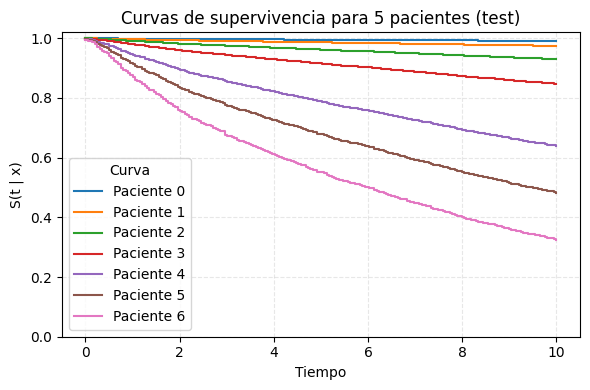

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Baseline cumulative hazard Λ0(t) usando SOLO el train
base_times, base_cumhaz = compute_baseline_cumhaz_breslow(
    train_time, train_event, train_scores
)

# 2) Malla de tiempos donde queremos evaluar S(t|x)
t_max = np.percentile(test_time, 95)   # por ejemplo hasta el percentil 95 del tiempo
time_grid = np.linspace(0, t_max, 200) # 200 puntos

# S_all tiene shape (n_test, len(time_grid)), cada fila S_all[i,:] es la curva de supervivencia en el tiempo marcado por el grid
S_all = surv_from_deepsurv(
    base_times, base_cumhaz,
    log_risk=test_scores,
    time_grid=time_grid
)

# Cogemos 5 pacientes que sean representativos con diferentes risk scores:

# ordenamos pacientes de test por riesgo (score)
idx_sorted = np.argsort(test_scores)    # scores pequeños → menos riesgo

n = len(idx_sorted)
# elegimos 5 índices repartidos a lo largo del ranking
chosen_idx = [
    idx_sorted[int(0.05 * n)],
    idx_sorted[int(0.25 * n)],
    idx_sorted[int(0.50 * n)],
    idx_sorted[int(0.75 * n)],
    idx_sorted[int(0.95 * n)],
    idx_sorted[int(0.99 * n)],
    idx_sorted[int(0.999 * n)],
]

# Dibujamos las 5 curvas de supervivencia
plt.figure(figsize=(6,4))

for k, idx in enumerate(chosen_idx):
    S_i = S_all[idx]          # curva de supervivencia del paciente idx
    plt.step(time_grid, S_i, where="post", label=f"Paciente {k}")

plt.xlabel("Tiempo")
plt.ylabel("S(t | x)")
plt.ylim(0, 1.02)
plt.title("Curvas de supervivencia para 5 pacientes (test)")
plt.legend(title="Curva")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
S_all

array([[0.99977493, 0.99969542, 0.9996291 , ..., 0.95628629, 0.95599069,
        0.95556023],
       [0.99961512, 0.99947916, 0.99936577, ..., 0.92640629, 0.92591661,
        0.92520371],
       [0.99941289, 0.99920552, 0.99903258, ..., 0.88992366, 0.88920613,
        0.88816187],
       ...,
       [0.99873587, 0.99828957, 0.99791746, ..., 0.77787876, 0.77652849,
        0.77456563],
       [0.99916747, 0.99887346, 0.99862829, ..., 0.84756374, 0.84659474,
        0.84518509],
       [0.99986413, 0.99981612, 0.99977608, ..., 0.97337797, 0.97319632,
        0.97293177]])

## Kaplan-Meier Curve

In [36]:
def kaplan_meier(time, event):
    """
    time: array de tiempos (días)
    event: array de indicadores (1=evento, 0=censura)
    Devuelve:
      t_unique: tiempos únicos en los que cambia la supervivencia
      S:       estimación de supervivencia KM en esos tiempos
    """
    # ordenamos por tiempo ascendente
    order = np.argsort(time)
    t_ord = time[order]
    e_ord = event[order]

    # tiempos únicos donde hay al menos un evento
    t_unique = np.unique(t_ord[e_ord == 1])
    S = []
    surv = 1.0

    n = len(t_ord)
    at_risk_start = 0  # índice del primero "en riesgo"

    for t in t_unique:
        # índice hasta el final de este tiempo t
        at_risk = n - at_risk_start

        # número de eventos exactamente en t
        d = np.sum((t_ord == t) & (e_ord == 1))

        if at_risk > 0:
            surv *= (1 - d / at_risk)
        S.append(surv)

        # avanzamos el índice de riesgo más allá de este tiempo
        at_risk_start = np.searchsorted(t_ord, t, side="right")

    return t_unique, np.array(S)


Supervivencia KM aproximada a 10 días: 0.878


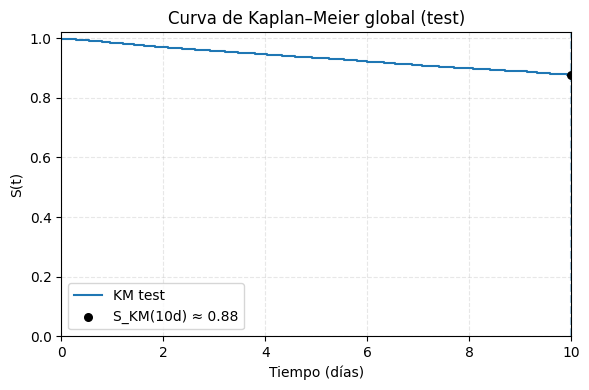

In [37]:
# curva KM global en test
km_t, km_S = kaplan_meier(test_time, test_event)

# estimamos S_KM(10) interpolando a mano (es una función escalón)
t_eval = 10.0  # días
# buscamos el último tiempo <= t_eval
idx = np.searchsorted(km_t, t_eval, side="right") - 2
if idx >= 0:
    S_10 = km_S[idx]
else:
    S_10 = 1.0  # si no ha habido eventos antes de 10 días

print(f"Supervivencia KM aproximada a 10 días: {S_10:.3f}")

## Graficar la curva a 10 días

plt.figure(figsize=(6,4))

# dibujamos solo hasta 10 días (o hasta el máximo si hay menos)
mask = km_t < t_eval
plt.step(km_t[mask], km_S[mask], where="post", label="KM test")

# marcamos el punto en t=10
plt.axvline(t_eval, linestyle="--", alpha=0.4)
plt.scatter([t_eval], [S_10], color="black", s=30, zorder=3,
            label=f"S_KM(10d) ≈ {S_10:.2f}")

plt.xlabel("Tiempo (días)")
plt.ylabel("S(t)")
plt.title("Curva de Kaplan–Meier global (test)")
plt.ylim(0, 1.02)
plt.xlim(0, t_eval)
plt.grid(alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()



In [38]:
S_10

0.8782038931054328

In [39]:
km_S

array([0.99988477, 0.99976953, 0.9996543 , 0.99953906, 0.9993086 ,
       0.99919336, 0.99907813, 0.99884766, 0.99873243, 0.99850196,
       0.99804102, 0.99746479, 0.9967733 , 0.99608174, 0.99550537,
       0.99492887, 0.9942369 , 0.99354494, 0.99331423, 0.99285265,
       0.99216005, 0.9919291 , 0.99112002, 0.99031047, 0.98949997,
       0.98938409, 0.98845618, 0.98752675, 0.98706104, 0.98647829,
       0.9857785 , 0.98507787, 0.98449353, 0.98402529, 0.98308812,
       0.9826192 , 0.98214995, 0.98179788, 0.98085802, 0.98015279,
       0.97932963, 0.9789765 , 0.97862287, 0.97767894, 0.97697064,
       0.97602523, 0.97543355, 0.97424805, 0.97353536, 0.97305942,
       0.97258237, 0.97210444, 0.97150556, 0.97126515, 0.97078349,
       0.97030081, 0.96969528, 0.96872486, 0.96799576, 0.96750891,
       0.96738702, 0.96689906, 0.96665474, 0.96616548, 0.96506325,
       0.96469533, 0.96432712, 0.96420423, 0.96383499, 0.96309491,
       0.96235321, 0.96148556, 0.96074012, 0.96036668, 0.95986

In [31]:
km_t

array([-0.8333333 , -0.7083333 , -0.5833333 , -0.5416667 , -0.45833334,
       -0.33333334, -0.25      , -0.08333334,  0.04166667,  0.08333334,
        0.125     ,  0.16666667,  0.20833333,  0.25      ,  0.29166666,
        0.33333334,  0.375     ,  0.41666666,  0.45833334,  0.5       ,
        0.5416667 ,  0.5833333 ,  0.625     ,  0.6666667 ,  0.7083333 ,
        0.75      ,  0.7916667 ,  0.8333333 ,  0.875     ,  0.9166667 ,
        0.9583333 ,  1.        ,  1.0416666 ,  1.0833334 ,  1.125     ,
        1.1666666 ,  1.2083334 ,  1.25      ,  1.2916666 ,  1.3333334 ,
        1.375     ,  1.4166666 ,  1.4583334 ,  1.5       ,  1.5416666 ,
        1.5833334 ,  1.625     ,  1.6666666 ,  1.7083334 ,  1.75      ,
        1.7916666 ,  1.8333334 ,  1.875     ,  1.9166666 ,  1.9583334 ,
        2.        ,  2.0416667 ,  2.0833333 ,  2.125     ,  2.1666667 ,
        2.2083333 ,  2.25      ,  2.2916667 ,  2.3333333 ,  2.375     ,
        2.4166667 ,  2.4583333 ,  2.5       ,  2.5416667 ,  2.58

In [32]:
mask

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [35]:

print("max(test_time):", np.max(test_time))
print("N pacientes con time == 10:", np.sum(test_time == 10))
print("De ellos, cuántos tienen event==1:",
      np.sum((test_time == 10) & (test_event == 1)))
print("De ellos, cuántos tienen event==0:",
      np.sum((test_time == 10) & (test_event == 0)))
print("N con time > 10:", np.sum(test_time > 10))


max(test_time): 10.0
N pacientes con time == 10: 2968
De ellos, cuántos tienen event==1: 0
De ellos, cuántos tienen event==0: 2968
N con time > 10: 0
